In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("Day 4 Started")


ModuleNotFoundError: No module named 'scipy'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("Day 4 Started")

ModuleNotFoundError: No module named 'scipy'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("Day 4 Started")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("Day 4 Started")

Day 4 Started


In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.head())
print(nav.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [5]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


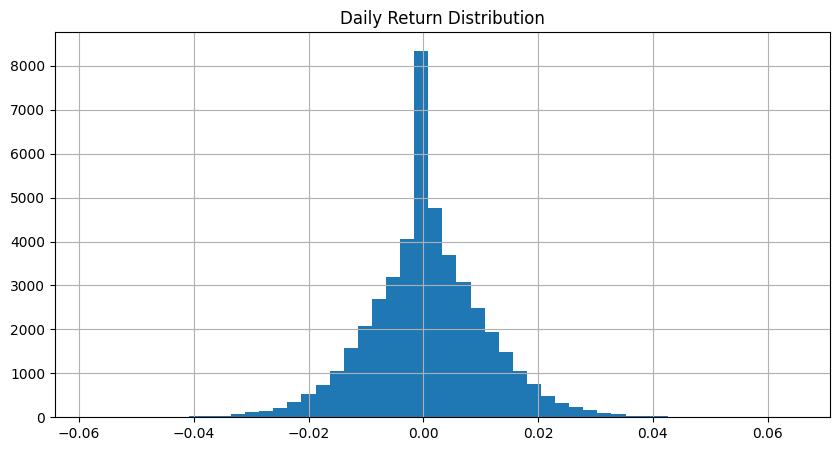

In [6]:
plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(bins=50)

plt.title("Daily Return Distribution")

plt.savefig(
    "../reports/daily_return_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [7]:
cagr_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp.iloc[-1]["date"] -
        temp.iloc[0]["date"]
    ).days / 365

    cagr = ((end_nav/start_nav)**(1/years)-1)*100

    cagr_list.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code","cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [8]:
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

print("CAGR saved")

CAGR saved


In [9]:
rf = 0.065

sharpe_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    returns = temp["daily_return"].dropna()

    if len(returns) > 0:

        sharpe = (
            (returns.mean()*252 - rf)
            /
            (returns.std()*np.sqrt(252))
        )

        sharpe_list.append(
            [fund, sharpe]
        )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code","sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [10]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Saved")

Sharpe Ratio Saved


In [11]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    returns = temp["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 0:

        downside_std = downside.std()

        sortino = (
            (returns.mean()*252 - rf)
            /
            (downside_std*np.sqrt(252))
        )

        sortino_list.append(
            [fund, sortino]
        )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code","sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [12]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio Saved")

Sortino Ratio Saved


In [13]:
maxdd_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        - 1
    )

    max_dd = temp["drawdown"].min()

    maxdd_list.append(
        [fund,max_dd]
    )

maxdd_df = pd.DataFrame(
    maxdd_list,
    columns=["amfi_code","max_drawdown"]
)

maxdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [14]:
maxdd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Max Drawdown Saved")

Max Drawdown Saved


In [16]:
benchmark = pd.read_csv(
    "../data/raw/06_benchmark_indices.csv"
)

benchmark.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/06_benchmark_indices.csv'

In [17]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', '118632.csv', '119092.csv', '119551.csv', '120503.csv', '120841.csv', '125497.csv']


In [18]:
import os

for f in os.listdir("../data/raw"):
    print(f)

01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
118632.csv
119092.csv
119551.csv
120503.csv
120841.csv
125497.csv


In [19]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.head())
print(benchmark.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='str')


In [20]:
scheme = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(scheme.head())
print(scheme.columns)

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [21]:
scorecard = scheme.copy()

scorecard["score"] = (
    scorecard["return_3yr_pct"].rank(pct=True) * 30 +
    scorecard["sharpe_ratio"].rank(pct=True) * 25 +
    scorecard["alpha"].rank(pct=True) * 20 +
    (1 / scorecard["expense_ratio_pct"]).rank(pct=True) * 15 +
    (1 / abs(scorecard["max_drawdown_pct"])).rank(pct=True) * 10
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard[
    ["amfi_code","scheme_name","score"]
].head(10)

,amfi_code,scheme_name,score
22,120843,Kotak Flexicap Fund - Regular - Growth,71.7500
2,119598,SBI Small Cap Fund - Regular Plan - Growth,70.6250
14,120507,ICICI Pru Liquid Fund - Regular - Growth,70.5000
9,100025,HDFC Short Term Debt Fund - Regular - Growth,70.2500
21,120842,Kotak Emerging Equity Fund - Regular - Growth,68.2500
3,119599,SBI Small Cap Fund - Direct Plan - Growth,68.0000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,66.6875
29,101207,ABSL Small Cap Fund - Regular - Growth,65.0000
23,120844,Kotak Liquid Fund - Regular - Growth,64.1250
33,102887,UTI Flexi Cap Fund - Regular - Growth,62.8125


In [22]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


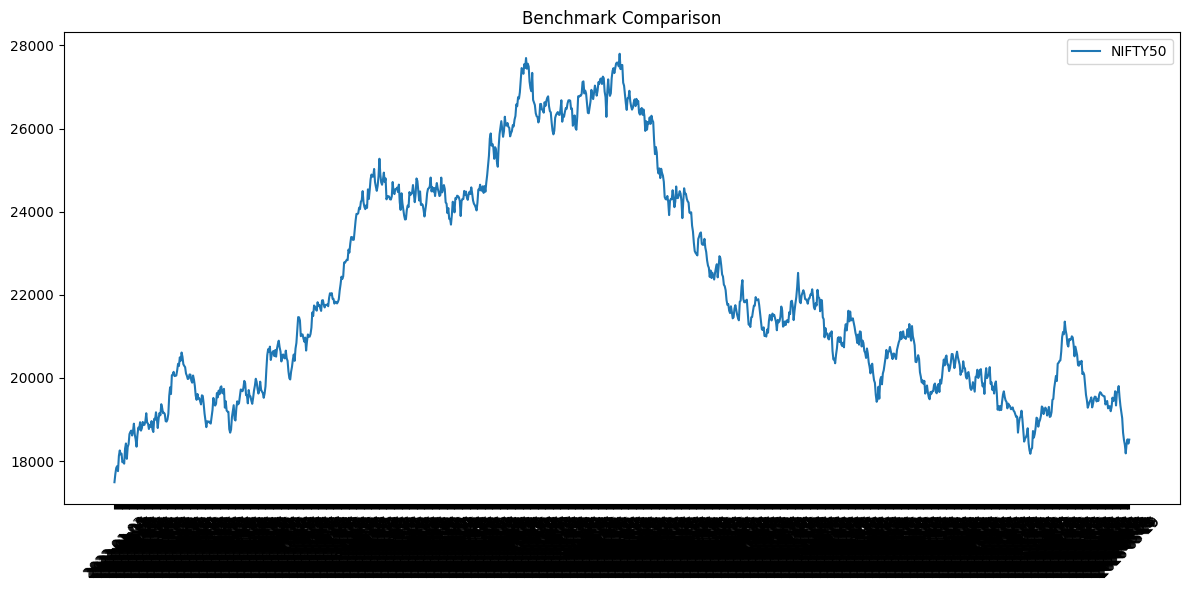

In [23]:
benchmark["close_value"] = benchmark["close_value"].astype(float)

nifty50 = benchmark[
    benchmark["index_name"]=="NIFTY50"
]

plt.figure(figsize=(12,6))

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    label="NIFTY50"
)

plt.title("Benchmark Comparison")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

In [24]:
tracking_error = abs(
    scheme["return_3yr_pct"].astype(float)
    -
    scheme["benchmark_3yr_pct"].astype(float)
)

scheme["tracking_error"] = tracking_error

scheme[
    ["scheme_name","tracking_error"]
].head()

,scheme_name,tracking_error
0,SBI Bluechip Fund - Regular Plan - Growth,0.87
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
2,SBI Small Cap Fund - Regular Plan - Growth,1.23
3,SBI Small Cap Fund - Direct Plan - Growth,1.13
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60


In [25]:
scheme[
    ["amfi_code","scheme_name","tracking_error"]
].to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error Saved")

Tracking Error Saved
